# Import Prerequisites

In [28]:
#import statements

import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from tabulate import tabulate

warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [29]:
case_time = pd.read_csv('districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [30]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [31]:
state = 'Karnataka'
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
128,2020-04-26,Karnataka,Bagalkote,24,6,1
129,2020-04-26,Karnataka,Ballari,13,5,0
130,2020-04-26,Karnataka,Belagavi,52,6,1
131,2020-04-26,Karnataka,Bengaluru Rural,6,5,0
132,2020-04-26,Karnataka,Bengaluru Urban,129,53,5
...,...,...,...,...,...,...
258161,2021-06-02,Karnataka,Tumakuru,104134,91392,911
258162,2021-06-02,Karnataka,Udupi,59441,53898,331
258163,2021-06-02,Karnataka,Uttara Kannada,45592,40420,583
258164,2021-06-02,Karnataka,Vijayapura,33405,31115,416


In [32]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [33]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [34]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [35]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2020
|| =============================== ||


In [36]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x
    print("=",end="")
            
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
print(" ||")

Preparing chronological district data for year 2021
|| =============================== ||


Trend of Active cases in Bengaluru Urban for the year 2020


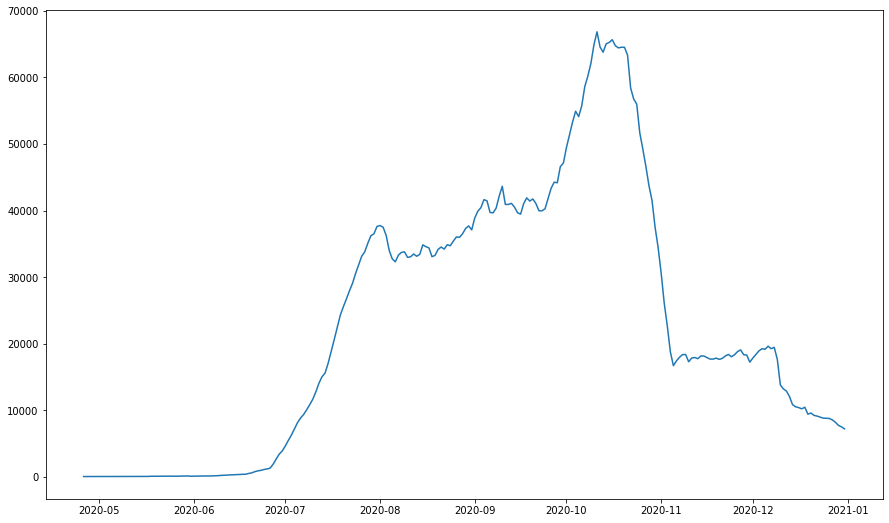

In [37]:
district = 'Bengaluru Urban'
pd.set_option('display.max_rows',466)
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of COVID-19 cases in Bengaluru Urban for the year 2021



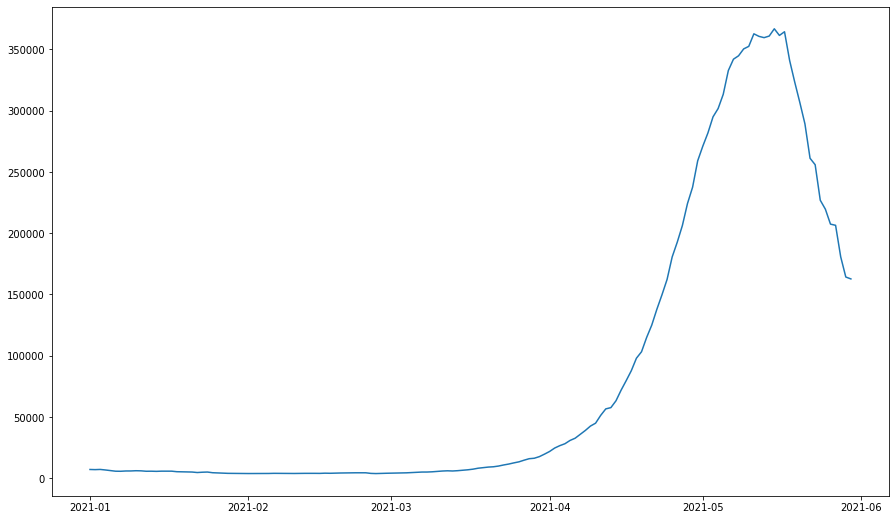

In [38]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of COVID-19 cases in",district,"for the year 2021\n")
plt.plot(bang_data_21)

In [39]:
quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Bengaluru Urban
            Active
Date              
2020-04-26      71
2020-04-27      72
2020-04-28      68
2020-04-29      68
2020-04-30      75
2020-05-01      67
2020-05-02      68
2020-05-03      71
2020-05-04      69
2020-05-05      72
2020-05-06      74
2020-05-07      73
2020-05-08      73
2020-05-09      83
2020-05-10      84
2020-05-11      80
2020-05-12      84
2020-05-13      82
2020-05-14      85
2020-05-15      94
2020-05-16      94
2020-05-17      87
2020-05-18     111
2020-05-19     115
2020-05-20     117
2020-05-21     125
2020-05-22     124
2020-05-23     127
2020-05-24     128
2020-05-25     117
2020-05-26     119
2020-05-27     123
2020-05-28     132
2020-05-29     144
2020-05-30     156
2020-05-31     118
2020-06-01     129
2020-06-02     141
2020-06-03     142
2020-06-04     149
2020-06-05     150
2020-06-06     163
2020-06-07     162
2020-06-08     177
2020-06-09     205
2020-06-10     245
2020-06-11     259
2020-06-12     291
2020-06-13     3

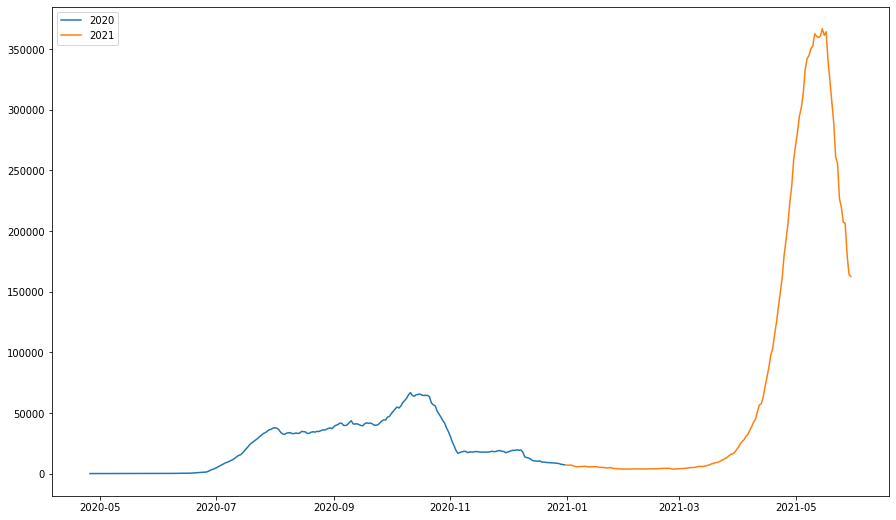

In [40]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# RNN Implementation

In [41]:

# univariate lstm example
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten


In [42]:
# preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
    X, y =[],[]
    for i in range(len(timeseries_data)):
        # find the end of this pattern
        end_ix = i + n_features
        # check if we are beyond the sequence
        if end_ix > len(timeseries_data)-1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [43]:
n_steps = 7  
n_features = 1
def prep_data(mod_data):
    # define input sequence
    timeseries_data = mod_data.values
    # choose a number of time steps
    # split into samples
    X, y = prepare_data(timeseries_data, n_steps)
    return X,y

In [44]:
def train_model(X,y):
    # reshape from [samples, timesteps] into [samples, timesteps, features]
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    # define model
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    # fit model
    model.fit(X, y, epochs=300, verbose=1)
    print(model.summary())
    
    return model


# Forecast over 1st test interval

In [45]:
# demonstrate prediction for next 10 days
def pred_nxt(days,dta):
    X, y = prep_data(dta)
    model = train_model(X,y)
    x_input = np.array(y[-8:])
    temp_input=list(x_input)
    lst_output=[]
    i=0
    while(i<days):

        if(len(temp_input)>3):
            x_input=np.array(temp_input[1:])
            print("{} day input {}".format(i,x_input))
            x_input = x_input.reshape((1, n_steps, n_features))
            yhat = model.predict(x_input, verbose=0)
            print("{} day output {}".format(i,yhat))
            temp_input.append(yhat[0][0])
            temp_input=temp_input[1:]
            #print(temp_input)
            lst_output.append(yhat[0][0])
            i=i+1
        else:
            print(x_input)
            x_input = x_input.reshape((1, n_steps, n_features))
            yhat = model.predict(x_input, verbose=0)
            print(yhat[0])
            temp_input.append(yhat[0][0])
            lst_output.append(yhat[0][0])
            i=i+1


    return (lst_output)

In [46]:
def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [47]:
rmse_for_tab = []
for i in range(1,15):
    period = int(i)
    ress = pred_nxt(i,bang_data)
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)

Epoch 1/300
243/243 [==============================] - 5s 21ms/sample - loss: 871645448.6914
Epoch 2/300
243/243 [==============================] - 0s 365us/sample - loss: 787135526.4527
Epoch 3/300
243/243 [==============================] - 0s 390us/sample - loss: 762725649.3827
Epoch 4/300
243/243 [==============================] - 0s 415us/sample - loss: 733640412.1811
Epoch 5/300
243/243 [==============================] - 0s 390us/sample - loss: 500512611.2346
Epoch 6/300
243/243 [==============================] - 0s 369us/sample - loss: 41214615.8354
Epoch 7/300
243/243 [==============================] - 0s 373us/sample - loss: 21936146.4527
Epoch 8/300
243/243 [==============================] - 0s 390us/sample - loss: 20909046.5144
Epoch 9/300
243/243 [==============================] - 0s 373us/sample - loss: 18653335.9671
Epoch 10/300
243/243 [==============================] - 0s 373us/sample - loss: 20173186.1893
Epoch 11/300
243/243 [==============================] - 0s 361us/

243/243 [==============================] - 0s 373us/sample - loss: 11638470.9198
Epoch 175/300
243/243 [==============================] - 0s 378us/sample - loss: 11593840.6749
Epoch 176/300
243/243 [==============================] - 0s 361us/sample - loss: 11308527.3457
Epoch 177/300
243/243 [==============================] - 0s 373us/sample - loss: 11631432.7572
Epoch 178/300
243/243 [==============================] - 0s 365us/sample - loss: 11757060.7984
Epoch 179/300
243/243 [==============================] - 0s 365us/sample - loss: 10744275.7037
Epoch 180/300
243/243 [==============================] - 0s 361us/sample - loss: 10171884.7654
Epoch 181/300
243/243 [==============================] - 0s 378us/sample - loss: 9067043.4897
Epoch 182/300
243/243 [==============================] - 0s 365us/sample - loss: 8284675.0118
Epoch 183/300
243/243 [==============================] - 0s 373us/sample - loss: 8209872.0288
Epoch 184/300
243/243 [==============================] - 0s 341us/s

243/243 [==============================] - 0s 378us/sample - loss: 2515360.1806
Epoch 262/300
243/243 [==============================] - 0s 365us/sample - loss: 2489526.4316
Epoch 263/300
243/243 [==============================] - 0s 365us/sample - loss: 2789892.5278
Epoch 264/300
243/243 [==============================] - 0s 365us/sample - loss: 2646129.5813
Epoch 265/300
243/243 [==============================] - 0s 365us/sample - loss: 2715517.8503
Epoch 266/300
243/243 [==============================] - 0s 365us/sample - loss: 2580632.6214
Epoch 267/300
243/243 [==============================] - 0s 378us/sample - loss: 2638711.7505
Epoch 268/300
243/243 [==============================] - 0s 439us/sample - loss: 2816487.0633
Epoch 269/300
243/243 [==============================] - 0s 357us/sample - loss: 3213742.4012
Epoch 270/300
243/243 [==============================] - 0s 361us/sample - loss: 3141212.9300
Epoch 271/300
243/243 [==============================] - 0s 365us/sample -

243/243 [==============================] - 0s 382us/sample - loss: 19474230.2551
Epoch 126/300
243/243 [==============================] - 0s 386us/sample - loss: 21237924.0700
Epoch 127/300
243/243 [==============================] - 0s 382us/sample - loss: 16869685.4208
Epoch 128/300
243/243 [==============================] - 0s 365us/sample - loss: 13901596.0247
Epoch 129/300
243/243 [==============================] - 0s 373us/sample - loss: 11233158.4527
Epoch 130/300
243/243 [==============================] - 0s 369us/sample - loss: 8821904.7171
Epoch 131/300
243/243 [==============================] - 0s 373us/sample - loss: 8206948.8066
Epoch 132/300
243/243 [==============================] - 0s 394us/sample - loss: 7726472.5206
Epoch 133/300
243/243 [==============================] - 0s 386us/sample - loss: 6056992.1420
Epoch 134/300
243/243 [==============================] - 0s 410us/sample - loss: 5725947.4558
Epoch 135/300
243/243 [==============================] - 0s 410us/sam

243/243 [==============================] - 0s 386us/sample - loss: 21123660.0823
Epoch 298/300
243/243 [==============================] - 0s 369us/sample - loss: 22232714.5761
Epoch 299/300
243/243 [==============================] - 0s 373us/sample - loss: 21338506.4362
Epoch 300/300
243/243 [==============================] - 0s 369us/sample - loss: 20376747.8272
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_36 (LSTM)               (None, 7, 50)             10400     
_________________________________________________________________
lstm_37 (LSTM)               (None, 50)                20200     
_________________________________________________________________
dense_18 (Dense)             (None, 1)                 51        
Total params: 30,651
Trainable params: 30,651
Non-trainable params: 0
_________________________________________________________________
None
0 day input [[8820]
 [8796]
 [8

...

243/243 [==============================] - 0s 480us/sample - loss: 17826950.9218
Epoch 112/300
243/243 [==============================] - 0s 480us/sample - loss: 18506647.1852
Epoch 113/300
243/243 [==============================] - 0s 488us/sample - loss: 17881626.0000
Epoch 114/300
243/243 [==============================] - 0s 484us/sample - loss: 18421966.2222
Epoch 115/300
243/243 [==============================] - 0s 525us/sample - loss: 23982293.9259
Epoch 116/300
243/243 [==============================] - 0s 521us/sample - loss: 22896521.4815
Epoch 117/300
243/243 [==============================] - 0s 488us/sample - loss: 18343824.0247 - loss: 16629300.90
Epoch 118/300
243/243 [==============================] - 0s 484us/sample - loss: 20806767.5391
Epoch 119/300
243/243 [==============================] - 0s 484us/sample - loss: 43886995.4403
Epoch 120/300
243/243 [==============================] - 0s 484us/sample - loss: 24205364.1852
Epoch 121/300
243/243 [=====================

243/243 [==============================] - 0s 480us/sample - loss: 3976475.7459
Epoch 285/300
243/243 [==============================] - 0s 480us/sample - loss: 3942897.2942
Epoch 286/300
243/243 [==============================] - 0s 484us/sample - loss: 3812075.2058
Epoch 287/300
243/243 [==============================] - 0s 480us/sample - loss: 4008509.3148
Epoch 288/300
243/243 [==============================] - 0s 493us/sample - loss: 3634260.2479
Epoch 289/300
243/243 [==============================] - 0s 480us/sample - loss: 3613950.2413
Epoch 290/300
243/243 [==============================] - 0s 480us/sample - loss: 3575091.7387
Epoch 291/300
243/243 [==============================] - 0s 488us/sample - loss: 3562115.1626
Epoch 292/300
243/243 [==============================] - 0s 484us/sample - loss: 3489223.0298
Epoch 293/300
243/243 [==============================] - 0s 480us/sample - loss: 3483731.0206
Epoch 294/300
243/243 [==============================] - 0s 480us/sample -

243/243 [==============================] - 0s 550us/sample - loss: 15014025.1811
Epoch 48/300
243/243 [==============================] - 0s 542us/sample - loss: 20655484.1070
Epoch 49/300
243/243 [==============================] - 0s 521us/sample - loss: 59463609.4321
Epoch 50/300
243/243 [==============================] - 0s 525us/sample - loss: 17330234.8189
Epoch 51/300
243/243 [==============================] - 0s 517us/sample - loss: 29224775.4650
Epoch 52/300
243/243 [==============================] - 0s 521us/sample - loss: 16839997.0700
Epoch 53/300
243/243 [==============================] - 0s 525us/sample - loss: 17905522.6996
Epoch 54/300
243/243 [==============================] - 0s 521us/sample - loss: 11728499.7243
Epoch 55/300
243/243 [==============================] - 0s 534us/sample - loss: 10256202.4527
Epoch 56/300
243/243 [==============================] - 0s 517us/sample - loss: 10276089.0021
Epoch 57/300
243/243 [==============================] - 0s 521us/sample -

243/243 [==============================] - 0s 521us/sample - loss: 7995189.3580
Epoch 220/300
243/243 [==============================] - 0s 521us/sample - loss: 7828000.3292
Epoch 221/300
243/243 [==============================] - 0s 521us/sample - loss: 9432123.2058
Epoch 222/300
243/243 [==============================] - 0s 517us/sample - loss: 8655988.9856
Epoch 223/300
243/243 [==============================] - 0s 517us/sample - loss: 7762879.3786
Epoch 224/300
243/243 [==============================] - 0s 529us/sample - loss: 7770497.6553
Epoch 225/300
243/243 [==============================] - 0s 546us/sample - loss: 6300736.0329
Epoch 226/300
243/243 [==============================] - 0s 534us/sample - loss: 6081185.2387
Epoch 227/300
243/243 [==============================] - 0s 521us/sample - loss: 6153646.0514
Epoch 228/300
243/243 [==============================] - 0s 517us/sample - loss: 5679369.8230
Epoch 229/300
243/243 [==============================] - 0s 525us/sample -

0 day output [[8318.499]]
1 day input [array([8796]) array([8576]) array([8226]) array([7751]) array([7535])
 array([7234]) 8318.499]
1 day output [[8598.997]]
2 day input [array([8576]) array([8226]) array([7751]) array([7535]) array([7234])
 8318.499 8598.997]
2 day output [[8224.787]]
3 day input [array([8226]) array([7751]) array([7535]) array([7234]) 8318.499 8598.997
 8224.787]
3 day output [[8291.816]]
4 day input [array([7751]) array([7535]) array([7234]) 8318.499 8598.997 8224.787
 8291.816]
4 day output [[8180.57]]
5 day input [array([7535]) array([7234]) 8318.499 8598.997 8224.787 8291.816 8180.57]
5 day output [[8119.927]]
6 day input [array([7234]) 8318.499 8598.997 8224.787 8291.816 8180.57 8119.927]
6 day output [[7914.6284]]
7 day input [8318.499  8598.997  8224.787  8291.816  8180.57   8119.927  7914.6284]
7 day output [[8161.5615]]
8 day input [8598.997  8224.787  8291.816  8180.57   8119.927  7914.6284 8161.5615]
8 day output [[8069.6777]]
9 day input [8224.787  8291

In [48]:
ress = pred_nxt(10,bang_data)

Epoch 1/300
243/243 [==============================] - 9s 37ms/sample - loss: 845752504.6255
Epoch 2/300
243/243 [==============================] - 0s 521us/sample - loss: 663149770.9300
Epoch 3/300
243/243 [==============================] - 0s 534us/sample - loss: 468679955.6214
Epoch 4/300
243/243 [==============================] - 0s 570us/sample - loss: 343191387.5885
Epoch 5/300
243/243 [==============================] - 0s 640us/sample - loss: 231795334.3868
Epoch 6/300
243/243 [==============================] - 0s 529us/sample - loss: 112129657.6955
Epoch 7/300
243/243 [==============================] - 0s 554us/sample - loss: 50475010.2222
Epoch 8/300
243/243 [==============================] - 0s 624us/sample - loss: 25702563.5967
Epoch 9/300
243/243 [==============================] - 0s 575us/sample - loss: 21419684.4938
Epoch 10/300
243/243 [==============================] - 0s 698us/sample - loss: 27048871.3745
Epoch 11/300
243/243 [==============================] - 0s 579us

243/243 [==============================] - 0s 521us/sample - loss: 10710688.7623
Epoch 174/300
243/243 [==============================] - 0s 521us/sample - loss: 10402999.4877
Epoch 175/300
243/243 [==============================] - 0s 517us/sample - loss: 10348744.9074
Epoch 176/300
243/243 [==============================] - 0s 517us/sample - loss: 10214982.7860
Epoch 177/300
243/243 [==============================] - 0s 517us/sample - loss: 10140076.7984
Epoch 178/300
243/243 [==============================] - 0s 517us/sample - loss: 9872019.0350
Epoch 179/300
243/243 [==============================] - 0s 525us/sample - loss: 9963139.8395
Epoch 180/300
243/243 [==============================] - 0s 525us/sample - loss: 9948301.3786
Epoch 181/300
243/243 [==============================] - 0s 517us/sample - loss: 9506025.2016
Epoch 182/300
243/243 [==============================] - 0s 521us/sample - loss: 9439738.3272
Epoch 183/300
243/243 [==============================] - 0s 517us/sam

Epoch 260/300
243/243 [==============================] - 0s 529us/sample - loss: 8208956.7716
Epoch 261/300
243/243 [==============================] - 0s 513us/sample - loss: 9275814.8560
Epoch 262/300
243/243 [==============================] - 0s 517us/sample - loss: 9798968.2922
Epoch 263/300
243/243 [==============================] - 0s 517us/sample - loss: 10137312.0165
Epoch 264/300
243/243 [==============================] - 0s 513us/sample - loss: 10986753.0864
Epoch 265/300
243/243 [==============================] - 0s 525us/sample - loss: 10791561.3210
Epoch 266/300
243/243 [==============================] - 0s 529us/sample - loss: 9543042.1502
Epoch 267/300
243/243 [==============================] - 0s 517us/sample - loss: 9525746.1728
Epoch 268/300
243/243 [==============================] - 0s 517us/sample - loss: 9364353.7356
Epoch 269/300
243/243 [==============================] - 0s 521us/sample - loss: 9674200.1070
Epoch 270/300
243/243 [==============================] - 

Forecast of trend of growth of COVID-19 for the 1st test interval
               Forecast  Daily forecast  Confidence interval  Actual  Daily
Date                                                                       
2021-01-01  7922.966797             688            92.892469    7086   -148
2021-01-02  7808.070312            -114            82.296908    6965   -121
2021-01-03  7726.186523             -82            89.738274    7123    158
2021-01-04  7707.944824             -19            97.261981    6692   -431
2021-01-05  7546.272949            -161            84.118100    6148   -544
2021-01-06  7578.074707              32            85.910255    5680   -468
2021-01-07  7597.420410              19            85.839987    5623    -57
2021-01-08  7497.083008            -100            92.502149    5860    237
2021-01-09  7454.995117             -43            93.855050    5877     17
2021-01-10  7410.944336             -44            95.443006    6069    192


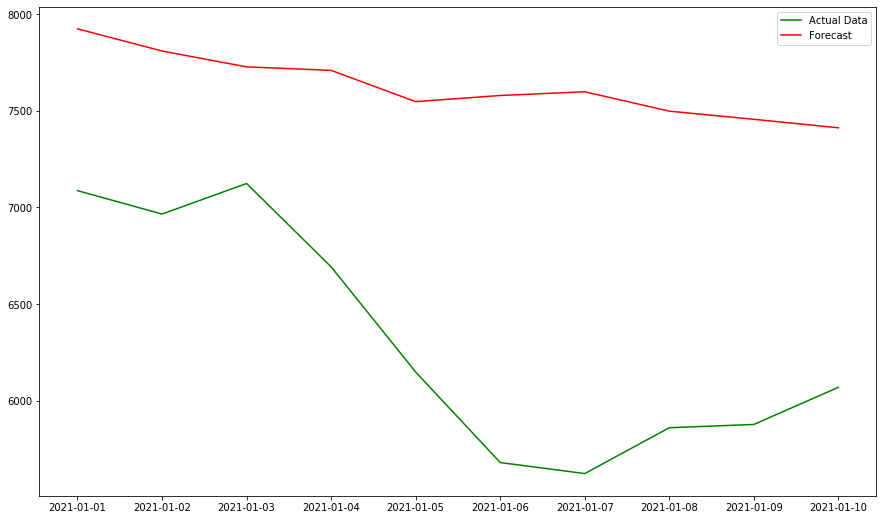

In [49]:
dt = bang_data.index[-1]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step

tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress

print("Forecast of trend of growth of COVID-19 for the 1st test interval")
daily = []
daily.append(int(ress[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab[:len(ress)]
tst['Actual'] = bang_data_21.values[:len(ress)]
cum = bang_data_21.values
daily = []
daily.append(int(cum[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(cum[i])-int(cum[i-1]))
tst['Daily'] = daily
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(tst['Actual'],color='green')
plt.plot(tst['Forecast'],color='red')
plt.legend(['Actual Data','Forecast'])

In [50]:
all_data = pd.concat([bang_data,bang_data_21])

In [51]:
dayss = 9
trdata = all_data[:-dayss]
tsdata = all_data[-dayss:]
ress = pred_nxt(dayss,trdata)

dt = trdata.index[-1]
end = dt + datetime.timedelta(days=dayss)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
cum = ress
dates = dtframe
daily = []
daily.append(cum[0]-bang_data[-1:].values)
data = []
for i in range(1,len(cum)):
    dd = []
    daily.append(cum[i]-cum[i-1])
    dts = tsdata.values[i] - tsdata.values[i-1]
    dd = [dates[i],int(daily[i]),int(cum[i]),rmse_for_tab[i],dts,tsdata.values[i]]
    data.append(dd)


Epoch 1/300
384/384 [==============================] - 10s 25ms/sample - loss: 345080106.6667
Epoch 2/300
384/384 [==============================] - 0s 654us/sample - loss: 257701429.8333
Epoch 3/300
384/384 [==============================] - 0s 540us/sample - loss: 242181076.3333
Epoch 4/300
384/384 [==============================] - 0s 543us/sample - loss: 209377806.5000
Epoch 5/300
384/384 [==============================] - 0s 538us/sample - loss: 169268390.0000
Epoch 6/300
384/384 [==============================] - 0s 535us/sample - loss: 179897790.8333
Epoch 7/300
384/384 [==============================] - 0s 538us/sample - loss: 203024694.1667
Epoch 8/300
384/384 [==============================] - 0s 538us/sample - loss: 226914721.0000
Epoch 9/300
384/384 [==============================] - 0s 535us/sample - loss: 276044724.3333
Epoch 10/300
384/384 [==============================] - 0s 543us/sample - loss: 197199425.6667
Epoch 11/300
384/384 [==============================] - 0s 

384/384 [==============================] - 0s 553us/sample - loss: 15773426.7292
Epoch 174/300
384/384 [==============================] - 0s 571us/sample - loss: 15582494.1250
Epoch 175/300
384/384 [==============================] - 0s 590us/sample - loss: 13971172.6458
Epoch 176/300
384/384 [==============================] - 0s 592us/sample - loss: 22439125.4792
Epoch 177/300
384/384 [==============================] - 0s 688us/sample - loss: 23072826.7917
Epoch 178/300
384/384 [==============================] - 0s 1ms/sample - loss: 14982032.3958
Epoch 179/300
384/384 [==============================] - 0s 665us/sample - loss: 11888459.9583
Epoch 180/300
384/384 [==============================] - 0s 595us/sample - loss: 12794693.5833
Epoch 181/300
384/384 [==============================] - 0s 597us/sample - loss: 11824937.1042
Epoch 182/300
384/384 [==============================] - 0s 595us/sample - loss: 11996804.4167 - loss: 11341504.
Epoch 183/300
384/384 [=========================

Epoch 259/300
384/384 [==============================] - 0s 543us/sample - loss: 12827862.1562
Epoch 260/300
384/384 [==============================] - ETA: 0s - loss: 11613418.57 - 0s 621us/sample - loss: 13181653.3125
Epoch 261/300
384/384 [==============================] - 0s 966us/sample - loss: 12091673.0208
Epoch 262/300
384/384 [==============================] - 0s 686us/sample - loss: 11801111.1667
Epoch 263/300
384/384 [==============================] - 0s 595us/sample - loss: 16589386.0833
Epoch 264/300
384/384 [==============================] - 0s 535us/sample - loss: 20532582.4062
Epoch 265/300
384/384 [==============================] - 0s 548us/sample - loss: 18592890.7500
Epoch 266/300
384/384 [==============================] - 0s 527us/sample - loss: 24712903.2083
Epoch 267/300
384/384 [==============================] - 0s 538us/sample - loss: 11640911.3542
Epoch 268/300
384/384 [==============================] - 0s 532us/sample - loss: 10119853.9583
Epoch 269/300
384/38

Forecast of trend of growth of COVID-19 for the 2nd test interval
Date          Daily    Cumulative    Confidence Interval    Daily    Cumulative
----------  -------  ------------  ---------------------  -------  ------------
2021-05-22   -17150        258281                82.2969    -5273        255843
2021-05-23   -14939        243342                89.7383   -28974        226869
2021-05-24   -13278        230063                97.262     -7317        219552
2021-05-25   -13781        216281                84.1181   -12194        207358
2021-05-26   -12355        203926                85.9103     -967        206391
2021-05-27   -11909        192016                85.84     -25693        180698
2021-05-28   -11312        180704                92.5021   -16515        164183
2021-05-29   -10387        170317                93.8551    -1557        162626


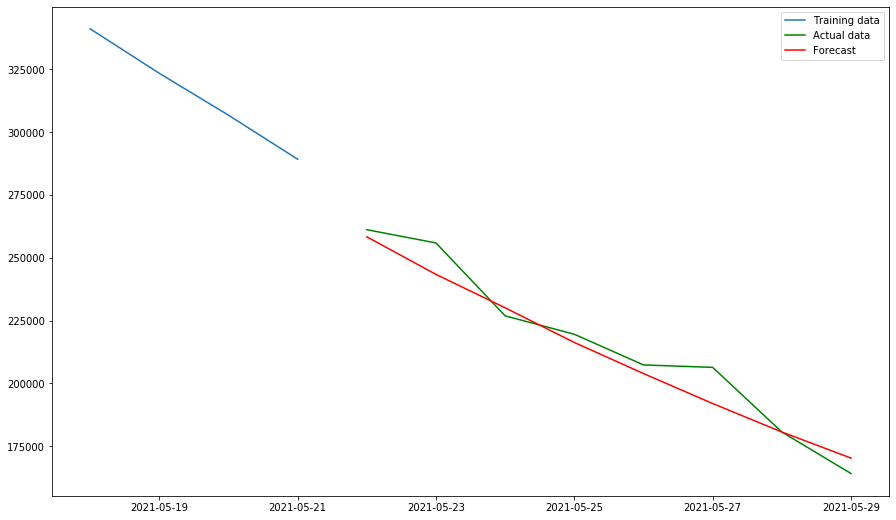

In [52]:
print("Forecast of trend of growth of COVID-19 for the 2nd test interval")
print(tabulate(data,headers=['Date','Daily','Cumulative','Confidence Interval','Daily','Cumulative']))
cum = [sub[2] for sub in data]
dts = [sub[0] for sub in data]
plt.plot(trdata[-int(dayss/2):])
plt.plot(tsdata[:len(cum)],color='green')
plt.plot(dts,cum,color = 'red')
plt.legend(['Training data','Actual data','Forecast'])

# Future forecast

In [53]:
all_data = pd.concat([bang_data,bang_data_21])
ress = pred_nxt(8,all_data)

Epoch 1/300
393/393 [==============================] - 10s 25ms/sample - loss: 10538455678.3715
Epoch 2/300
393/393 [==============================] - 0s 596us/sample - loss: 5435660142.7379
Epoch 3/300
393/393 [==============================] - 0s 576us/sample - loss: 536563392.3562
Epoch 4/300
393/393 [==============================] - 0s 789us/sample - loss: 532104511.5115
Epoch 5/300
393/393 [==============================] - 0s 815us/sample - loss: 540646880.1221
Epoch 6/300
393/393 [==============================] - 0s 604us/sample - loss: 374797173.5776
Epoch 7/300
393/393 [==============================] - 0s 571us/sample - loss: 343429618.4020
Epoch 8/300
393/393 [==============================] - 0s 571us/sample - loss: 349516813.5369
Epoch 9/300
393/393 [==============================] - 0s 568us/sample - loss: 665129520.9364
Epoch 10/300
393/393 [==============================] - 0s 579us/sample - loss: 1065913682.1934 - loss: 1260304347.
Epoch 11/300
393/393 [=============

393/393 [==============================] - 0s 553us/sample - loss: 59322190.6667
Epoch 172/300
393/393 [==============================] - 0s 556us/sample - loss: 47754467.6031
Epoch 173/300
393/393 [==============================] - 0s 561us/sample - loss: 35300337.3511
Epoch 174/300
393/393 [==============================] - 0s 556us/sample - loss: 57026418.6310
Epoch 175/300
393/393 [==============================] - 0s 561us/sample - loss: 46900914.3868
Epoch 176/300
393/393 [==============================] - 0s 563us/sample - loss: 42426593.1298
Epoch 177/300
393/393 [==============================] - 0s 558us/sample - loss: 41257593.8982
Epoch 178/300
393/393 [==============================] - 0s 546us/sample - loss: 29642834.5216
Epoch 179/300
393/393 [==============================] - 0s 561us/sample - loss: 33930821.0127
Epoch 180/300
393/393 [==============================] - 0s 558us/sample - loss: 35112190.8003
Epoch 181/300
393/393 [==============================] - 0s 558u

393/393 [==============================] - 0s 561us/sample - loss: 133837534.6743
Epoch 258/300
393/393 [==============================] - 0s 558us/sample - loss: 140798281.4046
Epoch 259/300
393/393 [==============================] - 0s 563us/sample - loss: 138391552.0214
Epoch 260/300
393/393 [==============================] - 0s 561us/sample - loss: 124695004.7468
Epoch 261/300
393/393 [==============================] - 0s 561us/sample - loss: 107632392.7125
Epoch 262/300
393/393 [==============================] - 0s 563us/sample - loss: 111682383.0280
Epoch 263/300
393/393 [==============================] - 0s 558us/sample - loss: 127394720.9695
Epoch 264/300
393/393 [==============================] - 0s 566us/sample - loss: 101209998.4936
Epoch 265/300
393/393 [==============================] - 0s 561us/sample - loss: 83035666.7150
Epoch 266/300
393/393 [==============================] - 0s 558us/sample - loss: 88997081.7430
Epoch 267/300
393/393 [==============================] -

Future forecast of COVID-19
                 Forecast  Daily forecast  Confidence interval
Date                                                          
2021-05-30  155407.984375           -7219            92.892469
2021-05-31  146199.468750           -9208            82.296908
2021-06-01  135286.015625          -10913            89.738274
2021-06-02  126917.320312           -8369            97.261981
2021-06-03  122592.601562           -4325            84.118100
2021-06-04  116103.164062           -6489            85.910255
2021-06-05  108732.625000           -7371            85.839987
2021-06-06  102102.859375           -6630            92.502149


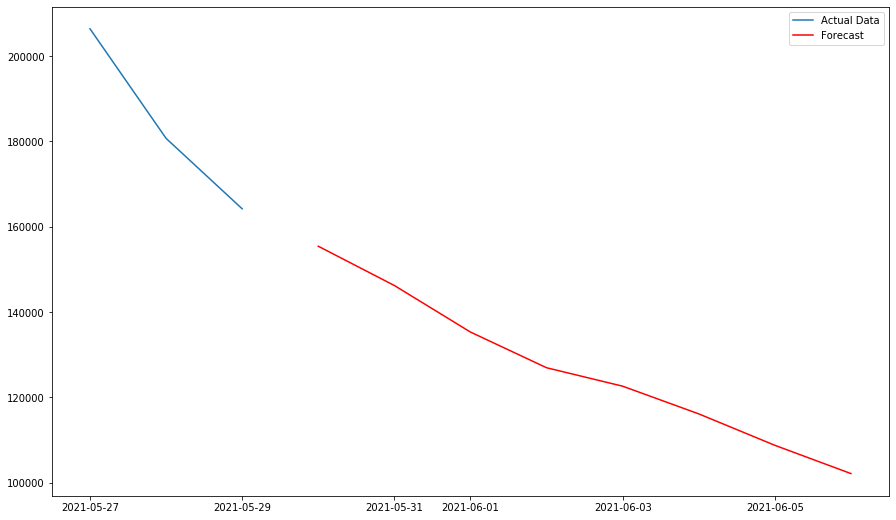

In [54]:
dt = all_data.index[-2]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step

print("Future forecast of COVID-19")
tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress

daily = []
daily.append(int(ress[0])-int(all_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab[:len(ress)]
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(all_data[-int(len(ress)/2):-1])
plt.plot(tst['Forecast'],color='red')
plt.legend(['Actual Data','Forecast'])